In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [49]:
SEED = 42
N_USERS = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
np.random.seed(42)

https://pubmed.ncbi.nlm.nih.gov/2043597/

tentukan ID, umur, gender, tinggi, dan berat awal. Kita kunci seed agar datanya tidak berubah-ubah saat di-run ulang.

In [50]:
user_ids = np.arange(1, N_USERS + 1)
ages = np.random.randint(17, 50, size=N_USERS)
genders = np.random.choice(['Male', 'Female'], size=N_USERS)
heights = np.random.randint(150, 200, size=N_USERS)
initial_weights = np.random.randint(40, 130, size=N_USERS)

df = pd.DataFrame({
    'User_ID': user_ids,
    'Age': ages,
    'Gender': genders,
    'Height_cm': heights,
    'Initial_Weight_kg': initial_weights
})

df.head()

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg
0,1,45,Male,181,53
1,2,31,Male,182,60
2,3,24,Female,150,87
3,4,37,Male,168,59
4,5,35,Male,151,47


menghitung dan mengklasifikasikan BMI : https://en.wikipedia.org/wiki/Body_mass_index

In [51]:
def calculate_bmi(weight_kg, height_cm):
    height_m = height_cm / 100
    return round(weight_kg / (height_m ** 2), 2)

In [52]:
df['Initial_BMI'] = calculate_bmi(
    df['Initial_Weight_kg'],
    df['Height_cm']
)

In [53]:
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    elif bmi > 30.0:
        return 'Obese'

# --- TERAPKAN KE DATASET ---
# Asumsi kolom 'Initial_BMI' sudah ada
df['BMI_Category'] = df['Initial_BMI'].apply(classify_bmi)

# Cek Hasil
print("Distribusi Kategori BMI User:")
print(df['BMI_Category'].value_counts())

display(df[['User_ID', 'Initial_BMI', 'BMI_Category']].head(10))

Distribusi Kategori BMI User:
BMI_Category
Obese          37
Underweight    25
Normal         21
Overweight     17
Name: count, dtype: int64


,User_ID,Initial_BMI,BMI_Category
0,1,16.18,Underweight
1,2,18.11,Underweight
2,3,38.67,Obese
3,4,20.90,Normal
4,5,20.61,Normal
5,6,12.35,Underweight
6,7,34.61,Obese
7,8,17.09,Underweight
8,9,29.97,Overweight
9,10,26.56,Overweight


calcuate bodyfat from BMI : https://en.wikipedia.org/wiki/Body_fat_percentage <br/><br/>
bodyfat category: <br/> https://www.bodybuildingmealplan.com/iifym-calculator/
![WhatsApp Image 2026-01-21 at 3.51.07 PM.jpeg](<attachment:WhatsApp Image 2026-01-21 at 3.51.07 PM.jpeg>)
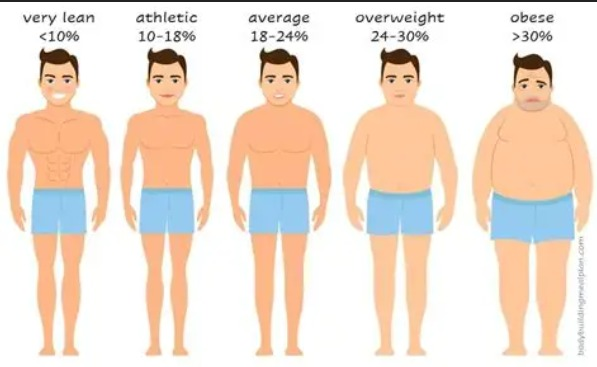

In [54]:
def calculate_fat_and_category(row):
  bmi = row['Initial_BMI']
  age = row['Age']
  gender = row['Gender']
  
  # --- 1. HITUNG BASE BODY FAT (Rumus Deurenberg) ---
  sex_val = 1 if gender == 'Male' else 0
  estimated_fat = (1.39 * bmi) + (0.16 * age) - (10.34 * sex_val) - 9
      
  # --- 2. TAMBAHKAN NOISE (Variasi) ---
  # Supaya data tidak 100% terpaku pada BMI. 
  # Kita beri variasi acak antara -3% sampai +3%
  noise = np.random.uniform(-3.0, 3.0)
  final_fat = estimated_fat + noise
  
  # --- 3. SAFETY GUARD (Batasan Biologis) ---
  # Batas minimal hidup: Pria ~3%, Wanita ~10%
  min_limit = 3.0 if gender == 'Male' else 10.0
  max_limit = 60.0 
  
  # Pastikan angka tidak minus atau di bawah batas biologis
  if final_fat < min_limit: 
      final_fat = min_limit
  elif final_fat > max_limit:
      final_fat = max_limit
      
  final_fat = round(final_fat, 1)
  
  # --- 4. TENTUKAN KATEGORI ---
  # Range: 
  # 1 (<10), 2 (10-18), 3 (18-24), 4 (24-30), 5 (>=30)
  
  category = 0
  if final_fat < 10:
    category = 1
  elif 10 <= final_fat < 18:
    category = 2
  elif 18 <= final_fat < 24:
    category = 3
  elif 24 <= final_fat < 30:
    category = 4
  else: # >= 30
    category = 5
      
  return category, final_fat

# --- EKSEKUSI ---
# Pastikan import numpy sudah ada
df[['Body_Fat_Category', 'Body_Fat_Percentage']] = df.apply(
  calculate_fat_and_category, axis=1, result_type='expand'
)

# Cek Hasil
print("Hasil Perhitungan Lemak & Kategori:")
display(df.head())


Hasil Perhitungan Lemak & Kategori:


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage
0,1,45,Male,181,53,16.18,Underweight,2.0,10.9
1,2,31,Male,182,60,18.11,Underweight,1.0,8.0
2,3,24,Female,150,87,38.67,Obese,5.0,45.8
3,4,37,Male,168,59,20.90,Normal,2.0,17.6
4,5,35,Male,151,47,20.61,Normal,2.0,14.1


memilih 3 category dalam pembentukan badan menurut : https://pmc.ncbi.nlm.nih.gov/articles/PMC3302369/

In [55]:
goals_options = ['Weight Loss', 'Muscle Gain', 'Maintain']
df['Goal'] = np.random.choice(goals_options, size=len(df))

function untuk menentukan batas wajar dari fat range dan akan digunakan untuk membantu menentukan goal

https://www.renuehealth.com/body-composition-analysis/

In [56]:
def get_healthy_fat_range(gender, age):
    """
    Mengembalikan tuple (min_limit, max_limit) berdasarkan tabel DEXA Scan.
    Range: 20th - 60th Percentile (Lean s.d. Average).
    
    ADJUSTMENT:
    - Usia < 20 (17-19) disamakan dengan kategori 20-29.
    - Usia 50 pas masuk ke kategori 50-59.
    """
    
    # --- LOGIKA UNTUK PRIA (MEN) ---
    if gender == 'Male':
        if age < 30:        # Mencakup 17 - 29 tahun
            return 15.0, 23.0
        elif age < 40:      # Mencakup 30 - 39 tahun
            return 16.0, 25.0
        elif age < 50:      # Mencakup 40 - 49 tahun
            return 18.0, 27.0
        else:               # Mencakup usia 50 (dan >50 jika ada data nyasar)
            return 19.0, 27.0

    # --- LOGIKA UNTUK WANITA (WOMEN) ---
    else:
        if age < 30:        # Mencakup 17 - 29 tahun
            return 24.0, 32.0
        elif age < 40:      # Mencakup 30 - 39 tahun
            return 26.0, 34.0
        elif age < 50:      # Mencakup 40 - 49 tahun
            return 26.0, 35.0
        else:               # Mencakup usia 50 (dan >50 jika ada data nyasar)
            return 29.0, 38.0

menentukan goal dari informasi BMI dan BodyFat <br/>
https://pmc.ncbi.nlm.nih.gov/articles/PMC2877506/

In [57]:
def set_goal(row):
  # --- AMBIL DATA ---
  bmi = row['Initial_BMI']
  body_fat = row['Body_Fat_Percentage']
  gender = row['Gender']
  age = row['Age']
  current_goal = row['Goal'] # Pilihan Random Awal
  
  # --- AMBIL BATAS LEMAK SEHAT (Panggil Fungsi Sebelumnya) ---
  min_fat, max_fat = get_healthy_fat_range(gender, age)
  
  # ====================================================================
  # LOGIKA PRIORITAS (SAFETY FIRST)
  # ====================================================================
  
  # 1. CEK UNDERWEIGHT (Kurus Bahaya) -> BMI < 18.5
  # Tidak peduli lemaknya berapa, orang ini butuh massa tubuh.
  # Jangan disuruh diet!
  if bmi < 18.5:
    return 'Muscle Gain'
      
  # 2. CEK OBESITAS SEJATI (BMI Tinggi & Lemak Tinggi)
  # BMI > 25 (Overweight) DAN Body Fat di atas batas normal
  elif bmi >= 25.0 and body_fat > max_fat:
    return 'Weight Loss'
      
  # 3. CEK "FALSE" OBESITAS (Kasus Atlet/Gym Rat)
  # BMI Tinggi (karena otot berat), TAPI Lemak Rendah/Normal
  elif bmi >= 25.0 and body_fat <= max_fat:
    # Orang ini kekar. Kalau random pilih Weight Loss, kita ganti.
    if current_goal == 'Weight Loss':
      return 'Maintain' # Atau Muscle Gain
    else:
      return current_goal
    
  # 4. CEK SKINNY FAT (BMI Normal, TAPI Lemak Tinggi)
  # Badan kelihatan kurus berbaju, tapi perut buncit/lembek.
  elif 18.5 <= bmi < 25.0 and body_fat > max_fat:
    # Pilihan terbaik adalah "Body Recomposition" (Ubah lemak jadi otot).
    # Jadi kita paksa Muscle Gain (biar latihan beban) atau Weight Loss ringan.
    return 'Muscle Gain' 
    
  # 5. CEK TOO SHREDDED (Lemak terlalu rendah)
  elif body_fat < min_fat:
    return 'Muscle Gain' # Bulking
    
  # ====================================================================
  # KONDISI IDEAL (BMI Normal & Lemak Normal)
  # ====================================================================
  else:
    # Di sini kita mainkan Variasi agar tidak membosankan.
    # Karena badannya sudah bagus, kita hindari "Weight Loss" ekstrem.
    if current_goal == 'Weight Loss':
      # Daripada kurusin badan (ntar jadi ceking), mending kencangin otot
      return 'Muscle Gain'
    else:
      # Sisanya bebas (Maintain atau Muscle Gain sesuai mood user)
      return current_goal

df['Goal'] = df.apply(set_goal, axis=1)

menentukan workout frequency secara acak dari rentang 2-6 hari <br/>
kenapa memilih 2-6 hari : https://pubmed.ncbi.nlm.nih.gov/19204579/

In [58]:
# A. FREKUENSI (Hari per Minggu)
# Referensi: Pemula 2-3 hari, Lanjut 4-6 hari. Kita random dengan bobot.
# 2 hari (20%), 3 hari (30%), 4 hari (30%), 5 hari (20%)
freq_probs = [0.2, 0.3, 0.3, 0.2]
df['Workout_Frequency'] = np.random.choice([2, 3, 4, 5], size=len(df), p=freq_probs)

# B. DURASI (Menit per Sesi)
# Referensi: WHO (Total mingguan harus 150+ menit).
# Pilihan: 30, 45, 60, 90 menit.
dur_probs = [0.2, 0.3, 0.3, 0.2]
df['Average_Duration_Minutes'] = np.random.choice([30, 45, 60, 90], size=len(df), p=dur_probs)

display(df.head())

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage,Goal,Workout_Frequency,Average_Duration_Minutes
0,1,45,Male,181,53,16.18,Underweight,2.0,10.9,Muscle Gain,2,90
1,2,31,Male,182,60,18.11,Underweight,1.0,8.0,Muscle Gain,3,45
2,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30
3,4,37,Male,168,59,20.90,Normal,2.0,17.6,Muscle Gain,3,30
4,5,35,Male,151,47,20.61,Normal,2.0,14.1,Muscle Gain,2,60


menentukan 3 level experience berdasarkan frequency latihan
https://pubmed.ncbi.nlm.nih.gov/19204579/

In [59]:
def determine_experience_level(row):
  freq = row['Workout_Frequency']

  # KITA PAKAI LOGIKA PROBABILITAS BERSYARAT
  # Biar datanya "Pintar" dan logis  
  # KASUS 1: JARANG LATIHAN (2-3 Hari)
  # Kemungkinan besar Beginner
  
  if freq == 0:
    return 'Beginner'

  if freq < 3:
    return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.70, 0.15, 0.15])
    
  # KASUS 2: RUTIN (4 Hari)
  # Campur rata
  elif freq == 3 or freq == 4:
    return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.15, 0.70, 0.15])
    
  # KASUS 3: HARDCORE (5-6 Hari)
  # Kemungkinan besar sudah berpengalaman
  else:
    # Beginner (10%), Intermediate (40%), Advanced (50%)
    return np.random.choice(['Beginner', 'Intermediate', 'Advanced'], p=[0.15, 0.15, 0.70])

# --- EKSEKUSI ---
# Asumsi kolom 'Workout_Frequency' sudah ada dari langkah sebelumnya
df['level'] = df.apply(determine_experience_level, axis=1)

# display(df.head(10))

membuat external exercises (olahraga umum)

In [60]:
def external_exercises(row):
    gender = row['Gender']
    
    # Keterangan: 0 = Tidak Main, 1 = Main
    
    # 1. BADMINTON (Sangat Populer)
    # 80% orang bisa/suka main badminton
    badminton = np.random.choice([0, 1], p=[0.2, 0.8])
    
    # 2. FOOTBALL / FUTSAL (Dominan Pria)
    if gender == 'Male':
        # Cowok: 70% suka main bola
        football = np.random.choice([0, 1], p=[0.3, 0.7])
    else:
        # Cewek: 10% suka main bola/futsal
        football = np.random.choice([0, 1], p=[0.9, 0.1])

    # 3. BASKETBALL
    # Sekitar 30% orang main basket
    basketball = np.random.choice([0, 1], p=[0.7, 0.3])

    # 4. TENNIS (Niche/Jarang)
    # Cuma 10% yang main (karena alat/lapangan susah)
    tennis = np.random.choice([0, 1], p=[0.9, 0.1])
    
    # 5. VOLLEYBALL
    # Sekitar 25% orang main
    volleyball = np.random.choice([0, 1], p=[0.75, 0.25])
    
    # 6. TABLE TENNIS (Pingpong)
    # Sekitar 40% orang main (sering ada di kantor/kampung)
    table_tennis = np.random.choice([0, 1], p=[0.6, 0.4])

    # 7. TABLE TENNIS (Pingpong)
    # Sekitar 40% orang main (sering ada di kantor/kampung)
    Swim = np.random.choice([0, 1], p=[0.6, 0.4])

    return pd.Series([badminton, football, basketball, tennis, volleyball, table_tennis, Swim], 
                        index=['Badminton', 'Football', 'Basketball', 
                            'Tennis', 'Volleyball', 'Table_Tennis', 'Swim'])

# --- EKSEKUSI ---
# Generate data baru
df_games_binary = df.apply(external_exercises, axis=1)

# Gabungkan ke dataframe utama
df = pd.concat([df, df_games_binary], axis=1)

df.head()

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Tennis,Volleyball,Table_Tennis,Swim
0,1,45,Male,181,53,16.18,Underweight,2.0,10.9,Muscle Gain,2,90,Beginner,0,1,0,0,1,1,0
1,2,31,Male,182,60,18.11,Underweight,1.0,8.0,Muscle Gain,3,45,Beginner,1,0,1,0,0,1,1
2,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1
3,4,37,Male,168,59,20.90,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0
4,5,35,Male,151,47,20.61,Normal,2.0,14.1,Muscle Gain,2,60,Beginner,1,1,0,1,0,0,0


In [61]:
display(df[df['User_ID'] == 2].head(13))

# Cek Sample User 1 (Weight Loss - Intermediate)
display(df[df['User_ID'] == 1].head(13))

,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Tennis,Volleyball,Table_Tennis,Swim
1,2,31,Male,182,60,18.11,Underweight,1.0,8.0,Muscle Gain,3,45,Beginner,1,0,1,0,0,1,1


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category,Body_Fat_Category,Body_Fat_Percentage,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Tennis,Volleyball,Table_Tennis,Swim
0,1,45,Male,181,53,16.18,Underweight,2.0,10.9,Muscle Gain,2,90,Beginner,0,1,0,0,1,1,0


function untuk menghitung current calories <br/>
https://www.sfidn.com/article/post/cara-menghitung-bmr-dengan-rumus-dan-kalkulator-bmr

In [62]:
def get_current_calories(weight, height, age, gender, freq, goal_type):
    # 1. Hitung BMR (Mifflin-St Jeor) pakai BERAT SAAT INI
    if gender == 'Male':
        bmr = (10 * weight) + (6.25 * height) - (5 * age) + 5
    else:
        bmr = (10 * weight) + (6.25 * height) - (5 * age) - 161
    
    # 2. Faktor Aktivitas
    if freq <= 1: multiplier = 1.2
    elif freq <= 3: multiplier = 1.375
    elif freq <= 5: multiplier = 1.55
    else: multiplier = 1.725
    
    tdee = bmr * multiplier
    
    # 3. Target (Defisit/Surplus)
    if goal_type == 'Weight Loss':
        target = tdee - 500
    elif goal_type == 'Muscle Gain':
        target = tdee + 300
    else:
        target = tdee
    
    # Safety Limit (Gak boleh kelaparan)
    min_cal = 1500 if gender == 'Male' else 1200
    return max(int(target), min_cal)

menghitung water intake : <br/>
https://www.apnacalculator.com/tools/health/water-intake.php?utm_source=chatgpt.com

In [63]:
def get_water_needs(weight, duration):
  # Base: 35ml per kg berat badan
  base_water = weight * 35 
  
  # Extra: Sekitar 10-12ml per menit latihan
  # (Misal 60 menit latihan = nambah 600ml - 700ml)
  activity_water = duration * 10
  
  total_ml = base_water + activity_water
  return int(total_ml)

In [64]:
def enrich_nutrition_data(goal, calories):

    # 1. LOGIKA MACRO SPLIT (Sesuai Goal)
    if goal == 'Muscle Gain':
        # High Carb (50% C, 30% P, 20% F)
        p_ratio, c_ratio, f_ratio = 0.30, 0.50, 0.20
    elif goal == 'Weight Loss':
        # High Protein (40% P, 30% C, 30% F)
        p_ratio, c_ratio, f_ratio = 0.40, 0.30, 0.30
    else: # Maintain
        p_ratio, c_ratio, f_ratio = 0.30, 0.40, 0.30
        
    # Konversi ke Gram
    prot_g = int((calories * p_ratio) / 4)
    carbs_g = int((calories * c_ratio) / 4)
    fat_g = int((calories * f_ratio) / 9)
    
    # 2. LOGIKA MEAL FREQUENCY (Fleksibel sesuai total kalori)
    # Semakin banyak kalori, semakin sering harus makan biar gak begah.
    if calories < 1500:
        freq = 3 # 3x Makan Besar (No Snack)
    elif calories < 2200:
        freq = 4 # 3x Makan Besar + 1 Snack
    else:
        freq = 5 # 3x Makan Besar + 2 Snack
        
    return pd.Series([prot_g, carbs_g, fat_g, freq])

In [65]:
def get_additional_nutrients(calories):
    """
    Menghitung target micronutrients & batasan kesehatan
    berdasarkan rekomendasi umum (WHO/USDA).
    """
    # 1. FIBER (Serat)
    # USDA Guidelines: 14 gram serat per 1000 kalori
    fiber_g = int((calories / 1000) * 14)
    
    # 2. FREE SUGAR (Gula Tambahan)
    # WHO Guidelines: Maksimal 10% dari total kalori (ideal < 5%)
    # 1 gram gula = 4 kalori
    sugar_cal_limit = calories * 0.10
    sugar_g = int(sugar_cal_limit / 4)
    
    # 3. CHOLESTEROL
    # Standard Heart Health: Batasi di bawah 300mg per hari
    cholesterol_mg = 300
    
    # 4. CALSIUM
    # RDA (Recommended Dietary Allowance) umum dewasa: 1000mg
    calcium_mg = 1000
    
    return sugar_g, fiber_g, cholesterol_mg, calcium_mg

https://bodyrecomposition.com/muscle-gain/genetic-muscular-potential
https://pubmed.ncbi.nlm.nih.gov/21558571/
https://www.sciencedirect.com/science/article/pii/S0002916523277187?utm_source=chatgpt.com

In [66]:
def generate_time_series_progress(users_df, total_weeks=12):
    progress_list = []

    for index, row in users_df.iterrows():
        # --- AMBIL DATA AWAL ---
        user_id = row['User_ID']
        gender = row['Gender']
        height_m = row['Height_cm'] / 100
        start_weight = row['Initial_Weight_kg']
        start_fat = row['Body_Fat_Percentage']
        goal = row['Goal']
        level = row['level'] 
        
        height_cm = row['Height_cm']
        age = row['Age']                   
        freq = row['Workout_Frequency']
        duration_min = row['Average_Duration_Minutes']
        
        current_weight = start_weight
        current_fat = start_fat
        
        calories = get_current_calories(current_weight, height_cm, age, gender, freq, goal)
        water = get_water_needs(current_weight, duration_min)
        prot_g, carbs_g, fat_g, freq_meal = enrich_nutrition_data(goal, calories)
        sugar_g, fiber_g, chol_mg, calc_mg = get_additional_nutrients(calories)

        # --- MINGGU 0 (INPUT DATA AWAL) ---
        progress_list.append({
            'User_ID': user_id,
            'Week': 0,
            'Weight_kg': round(current_weight, 2),
            'BMI': round(current_weight / (height_m**2), 2),
            'Body_Fat_Percentage': round(current_fat, 1),
            'Daily_Calories': calories,
            'Daily_Water_ml': water,
            'Target_Protein_g': prot_g,
            'Target_Carbs_g': carbs_g,
            'Target_Fat_g': fat_g,
            'Limit_Sugar_g': sugar_g,
            'Target_Fiber_g': fiber_g,
            'Limit_Cholesterol_mg': chol_mg,
            'Target_Calcium_mg': calc_mg,
            'Meal_Frequency': freq_meal,
        })
        
        # --- LOOPING MINGGU 1 s/d 12 ---
        for week in range(1, total_weeks + 1):
            
            weight_change = 0
            fat_change = 0
            
            # ==============================================================================
            # LOGIKA 1: MUSCLE GAIN (ALAN ARAGON / HELMS MODEL)
            # Referensi: Helms et al. (2014) & Aragon's Rate of Gain
            # Menggunakan persentase berat badan per bulan dikonversi ke minggu.
            # ==============================================================================
            if goal == 'Muscle Gain':
                if level == 'Beginner':
                    # Target: ~1.0% - 1.5% BB per bulan (0.25% - 0.38% per minggu)
                    rate_pct = np.random.uniform(0.0025, 0.0038)
                elif level == 'Intermediate':
                    # Target: ~0.5% - 1.0% BB per bulan (0.12% - 0.25% per minggu)
                    rate_pct = np.random.uniform(0.0012, 0.0025)
                else: # Advanced
                    # Target: ~0.25% - 0.5% BB per bulan (0.06% - 0.12% per minggu)
                    rate_pct = np.random.uniform(0.0006, 0.0012)
                
                # Hitung kenaikan kg
                weight_gain_kg = current_weight * rate_pct
                
                # Tambah noise hidrasi (air)
                weight_change = weight_gain_kg + np.random.uniform(-0.1, 0.1)
                
                # Body Fat Change:
                # Karena otot naik (pembagi naik), persentase lemak biasanya turun sedikit atau stagnan
                # Asumsi surplus kalori bersih (Lean Bulk)
                fat_change = np.random.uniform(-0.3, 0.1)

            # ==============================================================================
            # LOGIKA 2: WEIGHT LOSS (HELMS 2014 GUIDELINE)
            # Referensi: "Caloric intake set to result in losses of 0.5 to 1%/wk"
            # ==============================================================================
            elif goal == 'Weight Loss':
                # Target: Turun 0.5% sampai 1.0% dari Berat Badan Saat Ini
                min_rate = 0.005 # 0.5%
                max_rate = 0.01  # 1.0%
                
                # Random di range aman tersebut
                loss_pct = np.random.uniform(min_rate, max_rate)
                target_loss_kg = current_weight * loss_pct
                
                # Tambah fluktuasi air (Non-linear weight loss)
                # Kadang air naik bikin berat stagnan (stall), kadang 'woosh effect'
                water_fluctuation = np.random.uniform(-0.5, 0.5)
                
                weight_change = -(target_loss_kg) + water_fluctuation
                
                # Body Fat Change:
                # Saat defisit, mayoritas yang hilang adalah lemak (jika protein cukup)
                # Estimasi kasar: lemak turun seiring berat turun
                fat_change = np.random.uniform(-0.8, -0.3)
            
            # ==============================================================================
            # LOGIKA 3: MAINTAIN (HOMEOSTASIS)
            # Referensi: Kreitzman et al. (1992) - Water/Glycogen fluctuations
            # ==============================================================================
            else:
                # Tidak ada target naik/turun, murni fluktuasi air
                weight_change = np.random.uniform(-0.5, 0.5)
                # Lemak relatif stabil
                fat_change = np.random.uniform(-0.2, 0.2)

            # --- UPDATE ANGKA ---
            current_weight += weight_change
            current_fat += fat_change
            
            # --- SAFETY GUARD (BIOLOGICAL LIMITS) ---
            # Helms 2014: "Risk of eating disorders" -> Jangan biarkan lemak terlalu rendah
            min_fat_limit = 5.0 if gender == 'Male' else 12.0 # Batas essential fat
            
            if current_fat < min_fat_limit: 
                current_fat = min_fat_limit
            
            # Hitung Ulang BMI
            new_bmi = current_weight / (height_m**2)
            
            temp_cal = get_current_calories(current_weight, height_cm, age, gender, freq, goal)
            temp_water = get_water_needs(current_weight, duration_min)
            temp_prot, temp_carb, temp_fat, temp_freq = enrich_nutrition_data(goal, temp_cal) # <--- Perbaiki param
            
            # Hitung Ulang Micro (Sementara)
            temp_sugar, temp_fiber, temp_chol, temp_calc = get_additional_nutrients(temp_cal)

            if week % 4 == 0:
                # Update Variabel Utama
                calories = temp_cal
                water = temp_water
                prot_g, carbs_g, fat_g, freq_meal = temp_prot, temp_carb, temp_fat, temp_freq
                
                # Update Variabel Micro Baru
                sugar_g, fiber_g, chol_mg, calc_mg = temp_sugar, temp_fiber, temp_chol, temp_calc

            # Simpan Data
            progress_list.append({
                'User_ID': user_id,
                'Week': week,
                'Weight_kg': round(current_weight, 2),
                'BMI': round(new_bmi, 2),
                'Body_Fat_Percentage': round(current_fat, 1),
                'Daily_Calories': calories,
                'Daily_Water_ml': water,
                'Target_Protein_g': prot_g,
                'Target_Carbs_g': carbs_g,
                'Target_Fat_g': fat_g,
                'Limit_Sugar_g': sugar_g,
                'Target_Fiber_g': fiber_g,
                'Limit_Cholesterol_mg': chol_mg,
                'Target_Calcium_mg': calc_mg,
                'Meal_Frequency': freq_meal
            })

    return pd.DataFrame(progress_list)

# --- CONTOH EKSEKUSI ---
df_weekly_progress = generate_time_series_progress(df, total_weeks=12)

In [67]:
display(df_weekly_progress[df_weekly_progress['User_ID'] == 3].head(16))
display(df_weekly_progress[df_weekly_progress['User_ID'] == 4].head(16))

,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency
26,3,0,87.00,38.67,45.8,1598,3345,159,119,53,39,22,300,1000,4
27,3,1,86.25,38.33,45.4,1598,3345,159,119,53,39,22,300,1000,4
28,3,2,85.40,37.95,44.9,1598,3345,159,119,53,39,22,300,1000,4
29,3,3,84.44,37.53,44.3,1598,3345,159,119,53,39,22,300,1000,4
30,3,4,83.64,37.17,43.9,1552,3227,155,116,51,38,21,300,1000,4
31,3,5,83.17,36.97,43.4,1552,3227,155,116,51,38,21,300,1000,4
32,3,6,82.78,36.79,42.7,1552,3227,155,116,51,38,21,300,1000,4
33,3,7,81.95,36.42,42.3,1552,3227,155,116,51,38,21,300,1000,4
34,3,8,80.86,35.94,41.9,1514,3130,151,113,50,37,21,300,1000,4
35,3,9,80.17,35.63,41.5,1514,3130,151,113,50,37,21,300,1000,4


,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency
39,4,0,59.00,20.90,17.6,2307,2365,173,288,51,57,32,300,1000,5
40,4,1,59.09,20.93,17.6,2307,2365,173,288,51,57,32,300,1000,5
41,4,2,59.22,20.98,17.4,2307,2365,173,288,51,57,32,300,1000,5
42,4,3,59.33,21.02,17.3,2307,2365,173,288,51,57,32,300,1000,5
43,4,4,59.46,21.07,17.3,2313,2381,173,289,51,57,32,300,1000,5
44,4,5,59.47,21.07,17.1,2313,2381,173,289,51,57,32,300,1000,5
45,4,6,59.61,21.12,17.0,2313,2381,173,289,51,57,32,300,1000,5
46,4,7,59.68,21.15,16.9,2313,2381,173,289,51,57,32,300,1000,5
47,4,8,59.89,21.22,16.7,2319,2396,173,289,51,57,32,300,1000,5
48,4,9,60.00,21.26,16.5,2319,2396,173,289,51,57,32,300,1000,5


link sama seperti diatas tadi

In [68]:
def get_bmi_category_label(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

# 2. Terapkan ke DataFrame Mingguan
# Asumsinya df_weekly_progress sudah kamu generate dari langkah sebelumnya
df_weekly_progress['BMI_Category'] = df_weekly_progress['BMI'].apply(get_bmi_category_label)

# --- CEK HASIL ---
display(df_weekly_progress[df_weekly_progress['User_ID'] == 3].head(13))

# Cek Sample User 1 (Weight Loss - Intermediate)
display(df_weekly_progress[df_weekly_progress['User_ID'] == 32].head(13))

,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category
26,3,0,87.00,38.67,45.8,1598,3345,159,119,53,39,22,300,1000,4,Obese
27,3,1,86.25,38.33,45.4,1598,3345,159,119,53,39,22,300,1000,4,Obese
28,3,2,85.40,37.95,44.9,1598,3345,159,119,53,39,22,300,1000,4,Obese
29,3,3,84.44,37.53,44.3,1598,3345,159,119,53,39,22,300,1000,4,Obese
30,3,4,83.64,37.17,43.9,1552,3227,155,116,51,38,21,300,1000,4,Obese
31,3,5,83.17,36.97,43.4,1552,3227,155,116,51,38,21,300,1000,4,Obese
32,3,6,82.78,36.79,42.7,1552,3227,155,116,51,38,21,300,1000,4,Obese
33,3,7,81.95,36.42,42.3,1552,3227,155,116,51,38,21,300,1000,4,Obese
34,3,8,80.86,35.94,41.9,1514,3130,151,113,50,37,21,300,1000,4,Obese
35,3,9,80.17,35.63,41.5,1514,3130,151,113,50,37,21,300,1000,4,Obese


,User_ID,Week,Weight_kg,BMI,Body_Fat_Percentage,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category
403,32,0,103.00,33.63,44.6,2224,4055,222,166,74,55,31,300,1000,5,Obese
404,32,1,102.44,33.45,44.2,2224,4055,222,166,74,55,31,300,1000,5,Obese
405,32,2,102.11,33.34,43.8,2224,4055,222,166,74,55,31,300,1000,5,Obese
406,32,3,101.53,33.15,43.4,2224,4055,222,166,74,55,31,300,1000,5,Obese
407,32,4,100.30,32.75,42.8,2182,3960,218,163,72,54,30,300,1000,4,Obese
408,32,5,99.66,32.54,42.2,2182,3960,218,163,72,54,30,300,1000,4,Obese
409,32,6,98.98,32.32,41.5,2182,3960,218,163,72,54,30,300,1000,4,Obese
410,32,7,98.53,32.17,40.7,2182,3960,218,163,72,54,30,300,1000,4,Obese
411,32,8,97.59,31.87,40.1,2140,3865,214,160,71,53,29,300,1000,4,Obese
412,32,9,97.07,31.70,39.7,2140,3865,214,160,71,53,29,300,1000,4,Obese


In [69]:
# --- PILIH KOLOM DARI DF PROFIL ---
# Kita ambil kolom penting saja biar tabel hasil merge tidak terlalu penuh

# --- LAKUKAN MERGE (LEFT JOIN) ---
# Gunakan 'left' join ke df_weekly_progress agar struktur mingguan tetap terjaga
df_merged = pd.merge(
    df,                       # Tabel kiri (Data Profil)
    df_weekly_progress,       # Tabel kanan (Data Mingguan)
    on='User_ID',             # Kunci Penghubung
    how='left'                # Jenis Join
)

# --- RAPIKAN URUTAN ---
# Urutkan biar enak dibaca: per User, lalu per Minggu
df_merged = df_merged.sort_values(by=['User_ID', 'Week'])

# --- CEK HASIL ---
# Tampilkan 1 user sampel (misal User 2 yang Muscle Gain)
print("Contoh Data Merged (User ID 2):")
display(df_merged[df_merged['User_ID'] == 3].head(12))

# Tampilkan 1 user sampel lain (misal User 1 yang Weight Loss)
print("\nContoh Data Merged (User ID 1):")
display(df_merged[df_merged['User_ID'] == 4].head(12))

Contoh Data Merged (User ID 2):


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category_x,Body_Fat_Category,Body_Fat_Percentage_x,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Tennis,Volleyball,Table_Tennis,Swim,Week,Weight_kg,BMI,Body_Fat_Percentage_y,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category_y
26,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,0,87.00,38.67,45.8,1598,3345,159,119,53,39,22,300,1000,4,Obese
27,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,1,86.25,38.33,45.4,1598,3345,159,119,53,39,22,300,1000,4,Obese
28,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,2,85.40,37.95,44.9,1598,3345,159,119,53,39,22,300,1000,4,Obese
29,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,3,84.44,37.53,44.3,1598,3345,159,119,53,39,22,300,1000,4,Obese
30,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,4,83.64,37.17,43.9,1552,3227,155,116,51,38,21,300,1000,4,Obese
31,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,5,83.17,36.97,43.4,1552,3227,155,116,51,38,21,300,1000,4,Obese
32,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,6,82.78,36.79,42.7,1552,3227,155,116,51,38,21,300,1000,4,Obese
33,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,7,81.95,36.42,42.3,1552,3227,155,116,51,38,21,300,1000,4,Obese
34,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,8,80.86,35.94,41.9,1514,3130,151,113,50,37,21,300,1000,4,Obese
35,3,24,Female,150,87,38.67,Obese,5.0,45.8,Weight Loss,2,30,Beginner,1,0,0,0,0,0,1,9,80.17,35.63,41.5,1514,3130,151,113,50,37,21,300,1000,4,Obese



Contoh Data Merged (User ID 1):


,User_ID,Age,Gender,Height_cm,Initial_Weight_kg,Initial_BMI,BMI_Category_x,Body_Fat_Category,Body_Fat_Percentage_x,Goal,Workout_Frequency,Average_Duration_Minutes,level,Badminton,Football,Basketball,Tennis,Volleyball,Table_Tennis,Swim,Week,Weight_kg,BMI,Body_Fat_Percentage_y,Daily_Calories,Daily_Water_ml,Target_Protein_g,Target_Carbs_g,Target_Fat_g,Limit_Sugar_g,Target_Fiber_g,Limit_Cholesterol_mg,Target_Calcium_mg,Meal_Frequency,BMI_Category_y
39,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,0,59.00,20.90,17.6,2307,2365,173,288,51,57,32,300,1000,5,Normal
40,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,1,59.09,20.93,17.6,2307,2365,173,288,51,57,32,300,1000,5,Normal
41,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,2,59.22,20.98,17.4,2307,2365,173,288,51,57,32,300,1000,5,Normal
42,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,3,59.33,21.02,17.3,2307,2365,173,288,51,57,32,300,1000,5,Normal
43,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,4,59.46,21.07,17.3,2313,2381,173,289,51,57,32,300,1000,5,Normal
44,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,5,59.47,21.07,17.1,2313,2381,173,289,51,57,32,300,1000,5,Normal
45,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,6,59.61,21.12,17.0,2313,2381,173,289,51,57,32,300,1000,5,Normal
46,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,7,59.68,21.15,16.9,2313,2381,173,289,51,57,32,300,1000,5,Normal
47,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,8,59.89,21.22,16.7,2319,2396,173,289,51,57,32,300,1000,5,Normal
48,4,37,Male,168,59,20.9,Normal,2.0,17.6,Muscle Gain,3,30,Intermediate,0,0,1,0,0,1,0,9,60.00,21.26,16.5,2319,2396,173,289,51,57,32,300,1000,5,Normal


In [70]:
df.to_csv('../../datas/dataset_users.csv', index=False)
df_merged.to_csv('../../datas/dataset_userprogress.csv', index=False)